<a href="https://colab.research.google.com/github/Ewha-Euron/10th-ML/blob/week_11/%EB%B3%B5%EC%8A%B5%EB%AC%B8%EC%A0%9C_11%EC%A3%BC%EC%B0%A8_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 11주차 복습과제: 군집화

다음은 11주차 군집화 세션의 복습과제입니다. 문제 조건에 맞춰 코드를 작성하고, 설명을 추가해 주세요.

---

#Section A: 군집화, K-means

문제 1: 좋은 군집화란?

좋은 군집화의 조건을 설명하시오.

**요구 사항**

군집 내부 응집도(Within-cluster similarity)의 의미를 설명하시오.

군집 간 분리도(Between-cluster dissimilarity)의 의미를 설명하시오.



군집 내부 응집도 (Within-cluster similarity): 군집 내에 속한 데이터 포인트들이 서로 얼마나 닮아(가까이) 있는지 나타내는 지표입니다. 좋은 군집화가 되려면 같은 군집 내 데이터 간의 거리가 최소화되어 내부 응집도가 높아야(거리의 합이 작아야) 합니다.

군집 간 분리도 (Between-cluster dissimilarity): 서로 다른 군집들이 얼마나 멀리 떨어져 명확히 구분되는지 나타내는 지표입니다. 좋은 군집화가 되려면 서로 다른 군집의 중심점(Centroid) 간의 거리가 최대화되어 군집 간 분리도가 높아야(명확히 분리되어야) 합니다.

문제 2: K-Means에서 군집 개수 K는 매우 중요한 파라미터이다.
동일한 데이터에 대해 서로 다른 K값을 적용했을 때 군집화 결과가 어떻게 달라지는지 비교하시오.

데이터 생성 조건
샘플 수 : 400개
군집 수 : 4개
특징 수 : 2개
random_state : 0
수행 조건

다음 K값에 대해 각각 군집화를 수행하시오.

Case 1 : K = 2
Case 2 : K = 4
Case 3 : K = 6
(배운 파라미터를 기반으로 작성하면 됨)

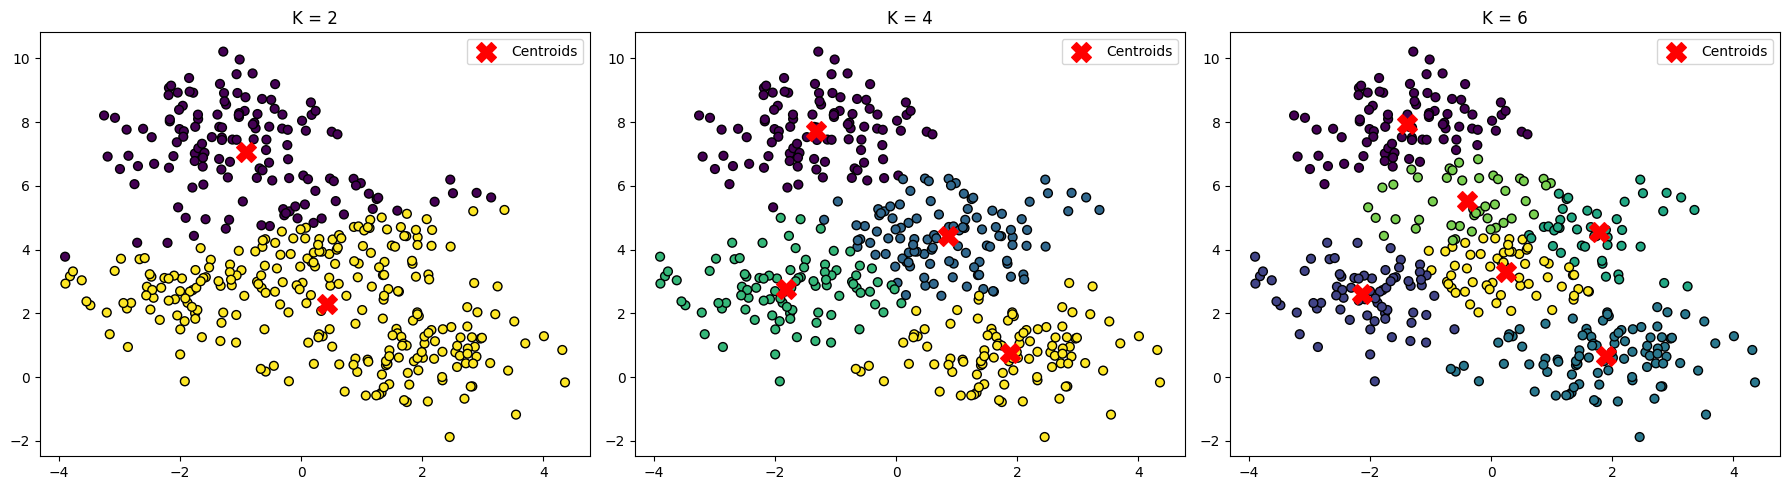

In [2]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=400, centers=4, n_features=2, random_state=0)

# K값 설정 리스트
k_values = [2, 4, 6]

# 시각화 설정
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, k in enumerate(k_values):
    kmeans = KMeans(n_clusters=k, random_state=0, n_init=10)
    labels = kmeans.fit_predict(X)

    # 군집화 결과 시각화
    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', marker='o', edgecolor='k', s=40)
    # 중심점(Centroid) 시각화
    axes[i].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                    s=200, c='red', marker='X', label='Centroids')
    axes[i].set_title(f'K = {k}')
    axes[i].legend()

plt.tight_layout()
plt.show()

문제 3 : Elbow Method - 최적 K찾기

K-Means는 사전에 K값을 지정해야 하기 때문에 적절한 군집 개수를 선택하는 과정이 중요하다. Elbow Method를 사용하여 최적의 군집 수를 탐색하시오. 데이터 생성 조건 샘플 수 : 500개 군집 수 : 5개 특징 수 : 2개 random_state : 10

수행 조건 K를 1부터 10까지 변화시키며 K-Means 수행

K값에 따른 SSE 그래프를 그리시오.

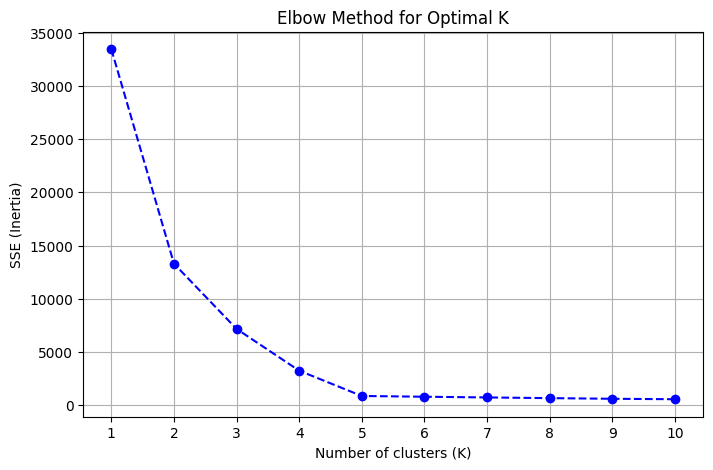

In [3]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(
    n_samples=500,
    centers=5,
    n_features=2,
    random_state=10
)

#K-means 수행 과정을 작성해주세요
sse = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=10, n_init=10)
    kmeans.fit(X)
    sse.append(kmeans.inertia_) # inertia_ 속성이 SSE를 의미함

# SSE 그래프 그리기
plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), sse, marker='o', linestyle='--', color='b')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('SSE (Inertia)')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()

문제 4: make_blobs를 이용해 2차원 데이터를 생성하고,
K=3으로 K-Means 군집화를 수행하시오.

centroid를 함께 시각화할 것
random_state=42 사용

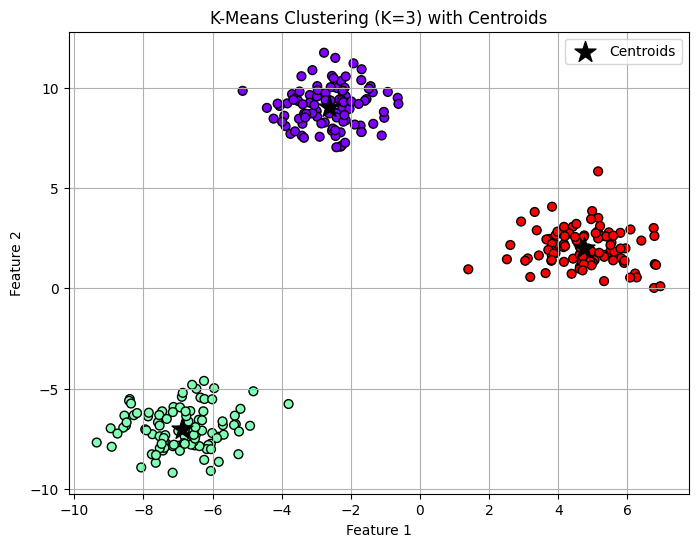

In [4]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# K-Means 군집화 (K=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='rainbow', edgecolor='k', s=40)
# 중심점 시각화
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=250, c='black', marker='*', label='Centroids')

plt.title('K-Means Clustering (K=3) with Centroids')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

문제 5:
iris 데이터셋에 대해
K=2
K=8로 각각 K-Means 군집화를 수행하고 결과를 시각화하시오.


이를 통해
K가 너무 작을 때의 문제점
K가 너무 클 때의 문제점을 서술하시오.

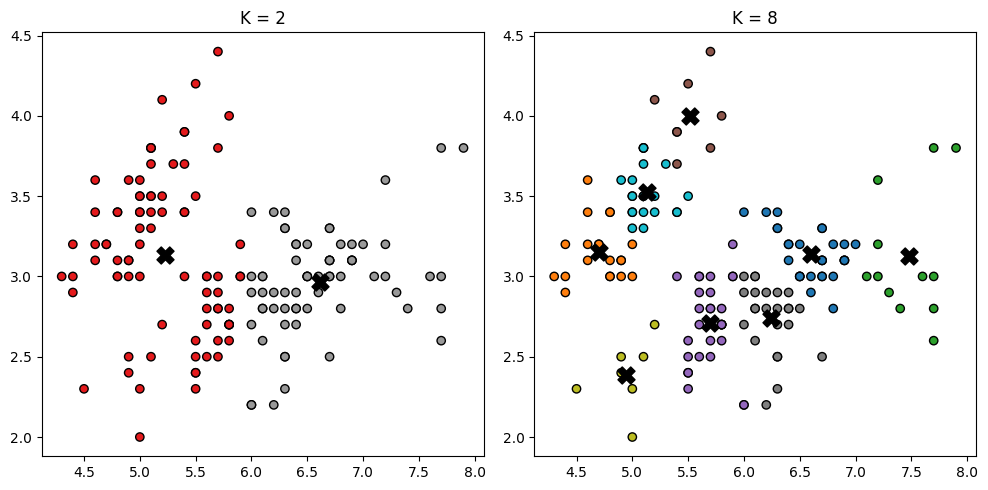

In [5]:
# iris data 불러오기
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# iris 데이터 불러오기
iris = load_iris()
X = iris.data[:, :2]   # 앞 2개 feature만 사용

# subplot 생성
fig, axes = plt.subplots(1, 2, figsize=(10,5))

# Case 1: K=2
kmeans_2 = KMeans(n_clusters=2, random_state=42, n_init=10)
labels_2 = kmeans_2.fit_predict(X)
axes[0].scatter(X[:, 0], X[:, 1], c=labels_2, cmap='Set1', edgecolor='k')
axes[0].scatter(kmeans_2.cluster_centers_[:, 0], kmeans_2.cluster_centers_[:, 1], s=150, c='black', marker='X')
axes[0].set_title('K = 2')

# Case 2: K=8
kmeans_8 = KMeans(n_clusters=8, random_state=42, n_init=10)
labels_8 = kmeans_8.fit_predict(X)
axes[1].scatter(X[:, 0], X[:, 1], c=labels_8, cmap='tab10', edgecolor='k')
axes[1].scatter(kmeans_8.cluster_centers_[:, 0], kmeans_8.cluster_centers_[:, 1], s=150, c='black', marker='X')
axes[1].set_title('K = 8')

plt.tight_layout()
plt.show()

K가 너무 작을 때의 문제점: 서로 다른 특징을 지닌 데이터 집합들이 하나의 군집으로 뭉뚱그려져, 데이터 내부의 잠재적인 세부 특징이나 클래스 구분을 제대로 분별해내지 못합니다(과소 군집화).

K가 너무 클 때의 문제점: 본질적으로 동일한 특성을 가진 하나의 군집이 무의미하게 파편화됩니다. 이는 군집의 개수가 과도하게 많아져 모델의 해석력을 떨어뜨리고 데이터 오버피팅(과적합)을 유발할 수 있습니다.

문제 6:

실루엣 계수(Silhouette Score)가 무엇인지 간단히 설명하시오.

실루엣 계수가 1, 0, 음수에 가까울 때 각각 어떤 의미를 가지는지 설명하시오.

실루엣 계수는 각 데이터 포인트가 자신이 속한 군집 내 다른 데이터와 얼마나 가깝고(응집도), 가장 가까운 이웃 군집과는 얼마나 멀리 떨어져 있는지(분리도)를 계산하여 군집화가 얼마나 잘 되었는지를 나타내는 정량적 지표입니다. $-1$에서 $1$ 사이의 값을 가집니다.

문제 7:
iris 데이터셋에 대해 다음 조건으로 K-Means 군집화를 수행하시오.

**요구사항**

군집화를 수행하고 결과를 시각화하시오.

cluster_centers_를 출력하시오.

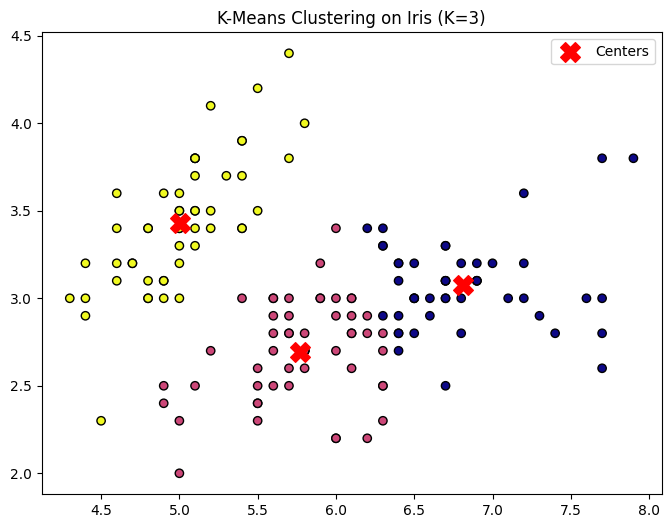

Cluster Centers:
 [[6.81276596 3.07446809]
 [5.77358491 2.69245283]
 [5.006      3.428     ]]


In [9]:
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 데이터 로드 및 전처리
iris = load_iris()
X = iris.data[:, :2]

# 주어진 조건으로 모델 생성
kmeans_detail = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

labels_detail = kmeans_detail.fit_predict(X)

# 결과 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_detail, cmap='plasma', edgecolor='k')
plt.scatter(kmeans_detail.cluster_centers_[:, 0], kmeans_detail.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centers')
plt.title('K-Means Clustering on Iris (K=3)')
plt.legend()
plt.show()

# cluster_centers_ 출력
print("Cluster Centers:\n", kmeans_detail.cluster_centers_)

문제 8: 다음 파라미터들의 역할을 간단히 설명하시오.

n_clusters

init

n_init

max_iter

random_state

n_clusters: 알고리즘이 형성할 군집(클러스터)의 개수이자 찾고자 하는 중심점(Centroid)의 개수입니다.

init: 초기 중심점을 설정하는 방식으로, 기본값인 'k-means++'는 초기 중심점들이 서로 최대한 멀리 떨어지도록 무작위 배치하여 알고리즘이 더 빠르게 수렴하도록 돕습니다.

n_init: 서로 다른 무작위 초기 중심점으로 K-Means 알고리즘을 독립적으로 반복 실행할 횟수입니다. 최적의 결과를 내는 최종 모델을 선택하게 해 줍니다.

max_iter: 중심점 이동 및 군집 재할당을 수행하는 단일 실행당 최대 반복 횟수입니다. 알고리즘이 이 횟수에 도달하면 중심점이 완전히 수렴하지 않아도 종료됩니다.

random_state: 중심점 초기화 시 무작위성을 제어하는 난수 생성 시드값으로, 코드를 다시 실행해도 언제나 동일한 군집화 결과를 보장(재현성)합니다.

### Section B: 평균 이동, GMM, DBSCAN

#### 문제 1: 평균 이동(Mean Shift) 군집화의 이해

Mean Shift 알고리즘은 KMeans와 유사하게 거리 기반 군집화 방법 중 하나입니다. 이 알고리즘의 동작 방식에 대해 간략히 설명하고, `make_blobs`를 사용하여 가상의 데이터셋을 생성한 후 `MeanShift`를 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

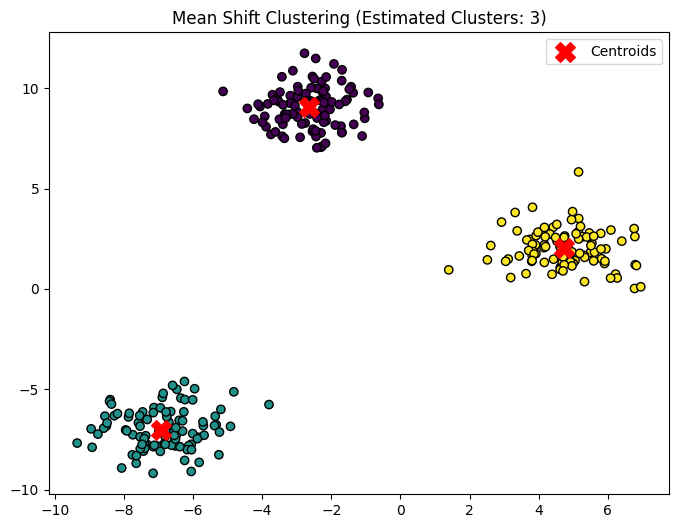

In [10]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# Mean Shift 적용
meanshift = MeanShift()
labels_ms = meanshift.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_ms, cmap='viridis', edgecolor='k')
plt.scatter(meanshift.cluster_centers_[:, 0], meanshift.cluster_centers_[:, 1], s=200, c='red', marker='X', label='Centroids')
plt.title(f'Mean Shift Clustering (Estimated Clusters: {len(meanshift.cluster_centers_)})')
plt.legend()
plt.show()

#### 문제 2: Mean Shift 군집화 파라미터 이해 및 조정

Mean Shift 알고리즘에서 `bandwidth` 파라미터는 군집화 결과에 큰 영향을 미칩니다. `bandwidth` 값을 다르게 설정했을 때 군집화 결과가 어떻게 달라지는지 확인하기 위해, 다음 조건을 따라 코드를 작성하고 결과를 비교하여 설명하세요.

**데이터 생성 조건:** (문제 1과 동일)
- 샘플 수: 300개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**MeanShift 설정:**
- Case 1: `bandwidth`를 `estimate_bandwidth`로 추정한 값 사용
- Case 2: `bandwidth`를 추정값의 0.5배로 설정
- Case 3: `bandwidth`를 추정값의 2배로 설정

각 Case별로 군집화 결과를 시각화하고, 군집의 개수 변화와 그 이유를 간략하게 설명하세요.

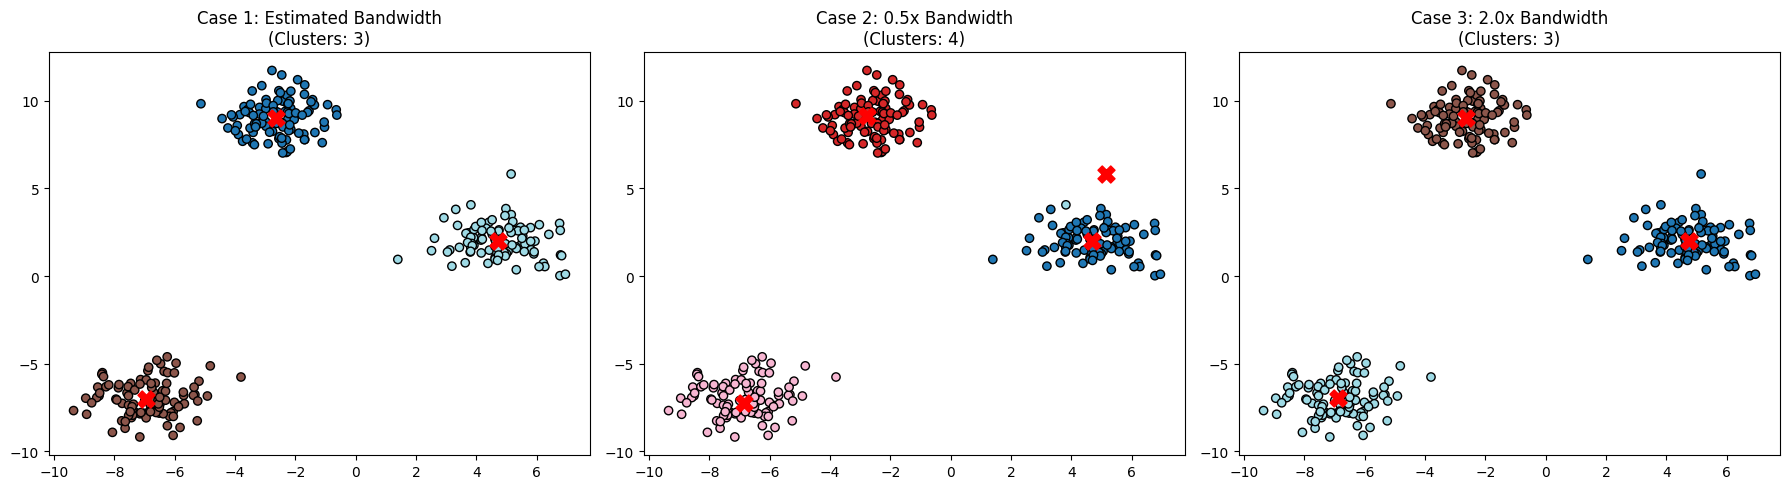

In [11]:
from sklearn.datasets import make_blobs
from sklearn.cluster import MeanShift, estimate_bandwidth
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=300, centers=3, n_features=2, random_state=42)

# 기준이 되는 추정 bandwidth 계산
base_bandwidth = estimate_bandwidth(X, random_state=42)

cases = [
    ('Case 1: Estimated Bandwidth', base_bandwidth),
    ('Case 2: 0.5x Bandwidth', base_bandwidth * 0.5),
    ('Case 3: 2.0x Bandwidth', base_bandwidth * 2.0)
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (title, bw) in enumerate(cases):
    ms = MeanShift(bandwidth=bw)
    labels = ms.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='tab20', edgecolor='k')
    if len(ms.cluster_centers_) > 0:
        axes[i].scatter(ms.cluster_centers_[:, 0], ms.cluster_centers_[:, 1], s=150, c='red', marker='X')
    axes[i].set_title(f'{title}\n(Clusters: {len(ms.cluster_centers_)})')

plt.tight_layout()
plt.show()

bandwidth가 너무 작을 때(Case 2): 좁은 영역 내에서만 중심을 찾으므로, 과도하게 세밀하게 밀집 지역을 인식하여 너무 많은 수의 군집이 생성됩니다.

bandwidth가 너무 클 때(Case 3): 너무 넓은 반경의 데이터를 하나로 뭉뚱그려 평균을 내기 때문에, 서로 다른 밀집 지역(군집)을 구별하지 못하고 단 하나의 군집으로 통합해 버립니다.

#### 문제 3: GMM (Gaussian Mixture Model) 군집화 및 KMeans와의 차이점

GMM은 각 군집이 가우시안 분포를 따른다고 가정하는 확률 기반 군집화 알고리즘입니다. GMM의 기본적인 개념과 KMeans와의 주요 차이점을 설명하고, `make_blobs`로 생성된 데이터에 `GaussianMixture`를 적용하여 군집화를 수행하고 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 400개
- 군집 수: 2개
- 특징 수: 2개
- 랜덤 시드: 0
- `cluster_std`를 각각 `[1.0, 2.5]`로 설정하여 타원형 분포를 갖도록 합니다.

**GMM 설정:**
- 군집 수: 2개
- 공분산 타입: `full`
- 랜덤 시드: 0

K-Means는 완벽한 구형(Circle) 형태의 데이터 군집화에는 유리하지만 정밀한 확률을 다루지 못하며, 거리 기반으로 딱딱하게 군집을 나누는 하드 군집화(Hard Clustering) 방식입니다. 반면, GMM은 전체 데이터가 여러 개의 가우시안(정규) 분포가 혼합된 것으로 가정하는 확률 기반의 소프트 군집화(Soft Clustering) 방식입니다. 이를 통해 각 군집이 타원형(Ellipsoid) 구조를 가질 수 있어 데이터 분포 형태 유연성이 뛰어납니다.

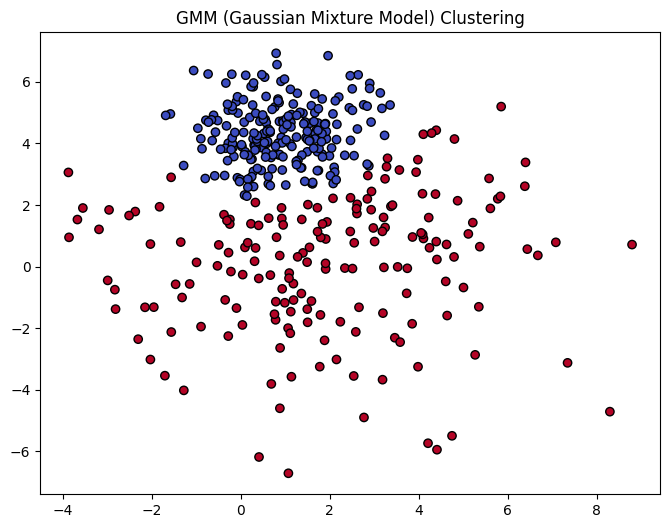

In [12]:
from sklearn.datasets import make_blobs
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# 데이터 생성 (타원형 분포 유도)
X, y = make_blobs(n_samples=400, centers=2, n_features=2, cluster_std=[1.0, 2.5], random_state=0)

# GMM 모델 생성 및 학습
gmm = GaussianMixture(n_components=2, covariance_type='full', random_state=0)
labels_gmm = gmm.fit_predict(X)

# 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_gmm, cmap='coolwarm', edgecolor='k')
plt.title('GMM (Gaussian Mixture Model) Clustering')
plt.show()

#### 문제 4: DBSCAN (밀도 기반 군집화) 알고리즘 적용

DBSCAN은 밀도 기반 군집화 방법으로, 군집의 개수를 미리 지정할 필요가 없으며 다양한 형태의 군집을 찾을 수 있습니다. DBSCAN의 주요 파라미터(`eps`, `min_samples`)와 데이터 포인트의 세 가지 유형(`Core`, `Border`, `Noise`)에 대해 설명하고, `make_moons`를 사용하여 초승달 모양 데이터셋을 생성한 후 `DBSCAN`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 200개
- 노이즈 비율: 0.05
- 랜덤 시드: 42

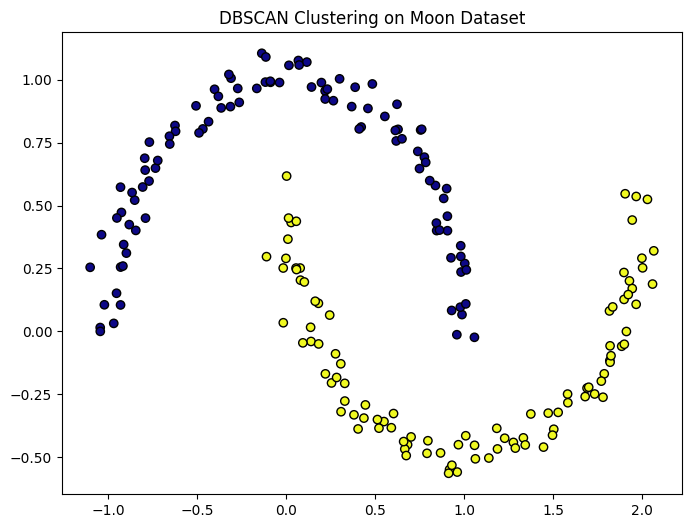

In [13]:
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

# 초승달 형태 데이터 생성
X, y = make_moons(n_samples=200, noise=0.05, random_state=42)

# DBSCAN 모델 생성 및 적용
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels_db = dbscan.fit_predict(X)

# 시각화 (DBSCAN에서 Noise는 대개 -1 레이블로 표현됩니다)
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_db, cmap='plasma', edgecolor='k')
plt.title('DBSCAN Clustering on Moon Dataset')
plt.show()

### Section C: 병합 군집, 계층적 군집, 고객 세그먼테이션 (RFM)

#### 문제 5: 계층적 군집화 (Agglomerative Clustering)의 이해

계층적 군집화는 데이터를 계층적으로 묶어 트리 형태(덴드로그램)의 구조를 만듭니다. 이 중 병합 군집(Agglomerative Clustering)의 개념에 대해 설명하고, `make_blobs`로 생성된 간단한 데이터셋에 `AgglomerativeClustering`을 적용하여 군집화를 수행하고 결과를 시각화하세요.

**데이터 생성 조건:**
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: `ward`

병합 군집(Agglomerative Clustering)은 상향식(Bottom-Up) 계층 군집화 방식입니다. 처음에 모든 데이터 포인트를 각각 하나의 독립된 개별 군집으로 취재한 뒤, 거리가 가장 가까운 군집 쌍을 반복적으로 병합해 가면서 최종적으로 목표한 군집 개수가 될 때까지 계층적 트리를 형성해 나갑니다.

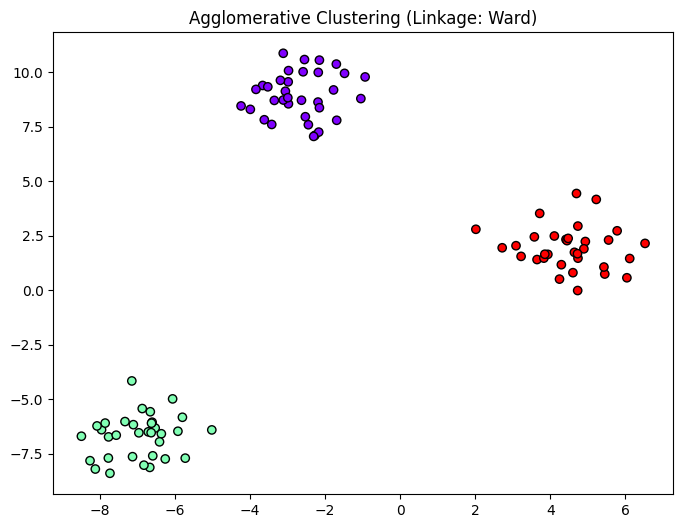

In [14]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

# 데이터 생성
X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

# 병합 군집 모델 객체 생성
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X)

# 결과 시각화
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels_agg, cmap='rainbow', edgecolor='k')
plt.title('Agglomerative Clustering (Linkage: Ward)')
plt.show()

#### 문제 6: 계층적 군집화의 Linkage 옵션

계층적 군집화에서 `linkage` 옵션은 군집 간의 유사성(거리)을 측정하는 방식을 정의하며, 군집화 결과에 중요한 영향을 미칩니다. `linkage` 옵션 중 `ward`, `complete`, `average` 세 가지 방식의 차이점을 간략히 설명하고, 다음 조건을 따라 `AgglomerativeClustering`을 적용하여 결과를 비교 시각화하세요.

**데이터 생성 조건:** (문제 5와 동일)
- 샘플 수: 100개
- 군집 수: 3개
- 특징 수: 2개
- 랜덤 시드: 42

**AgglomerativeClustering 설정:**
- 군집 수: 3개
- `linkage`: 각각 `ward`, `complete`, `average` 사용

ward: 두 군집이 병합되었을 때 발생하는 군집 내부 분산(Variance)의 증가량을 최소화하는 방향으로 군집을 병합합니다. 크기가 비교적 균등한 구형 군집을 만드는데 매우 효과적입니다.

complete (최장 연결법): 두 군집에 속한 모든 데이터 쌍 중에서 가장 먼 거리를 기준으로 군집 간 유사성을 측정합니다.

average (평균 연결법): 두 군집의 모든 데이터 포인트 쌍 간의 평균 거리를 기준으로 군집 간 유사성을 계산합니다.

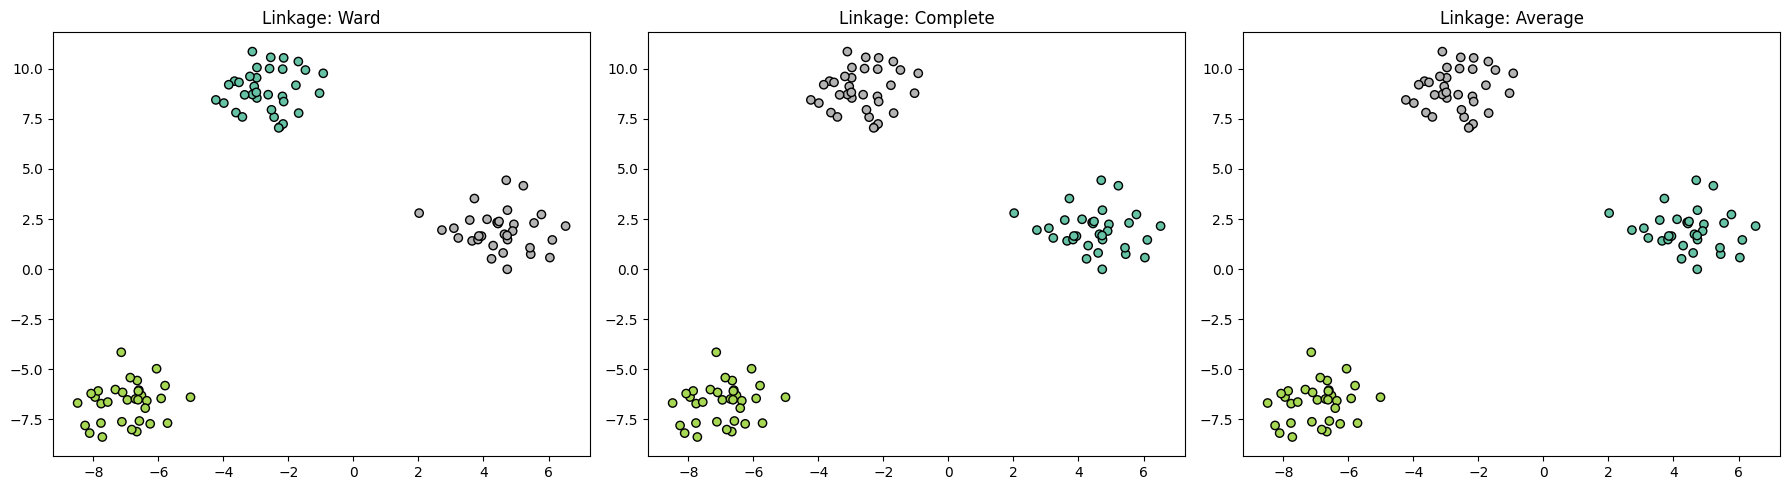

In [15]:
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=3, n_features=2, random_state=42)

linkages = ['ward', 'complete', 'average']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, link in enumerate(linkages):
    agg_model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = agg_model.fit_predict(X)

    axes[i].scatter(X[:, 0], X[:, 1], c=labels, cmap='Set2', edgecolor='k')
    axes[i].set_title(f'Linkage: {link.capitalize()}')

plt.tight_layout()
plt.show()

#### 문제 7: 고객 세그먼테이션 (RFM 기법)의 개념

고객 세그먼테이션은 마케팅 분야에서 고객을 유사한 특성별로 그룹화하는 데 사용됩니다. 이 중 RFM (Recency, Frequency, Monetary) 기법은 가장 널리 사용되는 방법 중 하나입니다. RFM 각 지표의 의미를 설명하고, 왜 이 세 가지 지표가 고객 가치를 평가하고 세그먼테이션하는 데 효과적인지 간략하게 서술하세요.

Recency (최근성): 고객이 가장 최근에 서비스를 이용하거나 상품을 구매한 시점이 언제인지를 측정합니다. (현재 혹은 특정 기준일과 가장 가까울수록 가치가 높음)

Frequency (활동 빈도): 정해진 분석 기간 동안 고객이 구매나 방문을 얼마나 자주 반복했는지 횟수를 측정합니다.

Monetary (구매 금액): 분석 기간 동안 고객이 구매 행동을 통해 지출한 총 누적 금액을 의미합니다.

기업 입장에서 큰 비용을 들이지 않고 확보할 수 있는 행동 데이터(구매 이력)만으로 구성되어 매우 직관적입니다. 또한 가장 가치 있는 VIP 고객(High R, F, M), 최근 이탈 조짐이 보이지만 잠재력 있는 고객(Low R, High F, M) 등을 정량적으로 쉽게 분류하여 각 타겟 세그먼트별 맞춤형 개인화 마케팅 전략을 수립하는 데에 가장 강력하고 효과적이기 때문입니다.

#### 문제 8: RFM 특징 데이터 전처리 및 생성

주어진 가상의 거래 데이터셋을 사용하여 RFM (Recency, Frequency, Monetary) 특징을 생성하세요. RFM은 고객 세그먼테이션을 위한 핵심 지표입니다. 각 RFM 지표를 계산하고, 최종적으로 고객별 RFM 데이터프레임을 생성하세요.

**데이터셋:** 다음 딕셔너리 형태의 데이터를 사용하여 `DataFrame`을 생성합니다.
```python
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
```

**계산 기준일:** `2023-03-01` (이 날짜를 기준으로 Recency를 계산합니다.)

**RFM 지표 계산:**
1. `PurchaseDate` 컬럼을 `datetime` 타입으로 변환합니다.
2. 각 고객(`CustomerID`)별로 다음 RFM 지표를 계산합니다.
   - **Recency:** `계산 기준일`로부터 가장 '최근' 구매일까지의 일수 (작을수록 좋음)
   - **Frequency:** 일정 기간 동안의 총 구매 '횟수'
   - **Monetary:** 일정 기간 동안의 총 구매 '금액' (Price의 합계)
3. 최종적으로 `CustomerID`, `Recency`, `Frequency`, `Monetary` 컬럼을 포함하는 RFM 데이터프레임을 생성하고 첫 5행을 출력합니다.

In [16]:
import pandas as pd

# 1. 원본 데이터 세팅 및 데이터프레임 생성
data = {
    'CustomerID': [1, 1, 1, 2, 2, 3, 3, 3, 3, 4, 4, 5, 5],
    'PurchaseDate': ['2023-01-10', '2023-01-15', '2023-02-01', '2023-01-20', '2023-02-10', '2023-01-05', '2021-03-01', '2023-02-15', '2023-02-20', '2023-01-25', '2023-02-05', '2023-01-01', '2023-01-08'],
    'Price': [100, 150, 200, 50, 120, 300, 100, 150, 80, 250, 70, 500, 100]
}
df = pd.DataFrame(data)

# 2. PurchaseDate 컬럼을 datetime 타입으로 변환
df['PurchaseDate'] = pd.to_datetime(df['PurchaseDate'])

# 3. 계산 기준일 설정
target_date = pd.to_datetime('2023-03-01')

# 4. 고객별 RFM 지표 집계 계산
# Recency 계산을 위해 기준일과 구매일의 차이를 구함
df['RecencyDays'] = (target_date - df['PurchaseDate']).dt.days

rfm_df = df.groupby('CustomerID').agg({
    'RecencyDays': 'min',     # 기준일로부터 가장 최근(작은 일수 차이) 구매일
    'PurchaseDate': 'count',  # 총 구매 건수 (Frequency)
    'Price': 'sum'            # 총 구매 금액합 (Monetary)
}).reset_index()

# 5. 컬럼명 정제 변경
rfm_df.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# 6. 첫 5행 결과 출력
print(rfm_df.head())

   CustomerID  Recency  Frequency  Monetary
0           1       28          3       450
1           2       19          2       170
2           3        9          4       630
3           4       24          2       320
4           5       52          2       600
